# Model Reference Adaptive Control

Based on the paper and the videos of Tansel Yucelen

## General principles: Standard matched uncertainty

### Nonlinear Uncertain Dynamical System

Let's consider the nonlinear uncertain dynamical system of the form:
$$
\dot{x}(t) = Ax(t) + B[u(t)+\Delta(x(t))], \quad x(0) = x_0
$$

Where:
* $x(t) \in \mathbb{R}^n$ is the state vector
* $u(t) \in \mathbb{R}^m$ is the control ouput
* $A \in \mathbb{R}^{n\times n}$ is a **known** system matrix
* $B \in \mathbb{R}^{m \times m}$ is a **known** input matrix
* $\Delta: \mathbb{R}^{n} \to \mathbb{R}^{m}$ is the **matched uncertainty**. This models for example aerodynamic drag as a function of state, unknown but state-dependent thrust coefficients, payload changes that don't alter the geometry.

The uncertainty $\Delta : \mathbb{R}^n \to \mathbb{R}^m$ enters *through the same channel* as the control input $B$. This is the **matched uncertainty condition** — formally, $\Delta(x) \in \text{range}(B)$, i.e. the uncertainty can be written as $B \times f(\cdot))$.

Pd: the pair $(A, B)$ is controllable

### Uncertainty Parameterization
Let's assume the uncertainty follows the form:
$$
\Delta(x) = W^\top \beta(x), \quad x \in \mathbb{R}^{n}
$$
Where:
* $W \in \mathbb{R}^{s \times m}$ is an **unknown** constant weight matrix
* $\beta: \mathbb{R}^{n} \to \mathbb{R}^{s}$ is a **known** basis function


### Nominal control design and the reference model selection

Since we know something about the system (that's the reason we have a model as reference), we would like to create one controller for this nominal system.
For the nominal control design we assume we don't have uncertainty. In other words we assume $\Delta(x(t)) = 0$, and thus the dynamical system reduces to the canonical form:
$$
\dot{x}(t) = Ax(t) + Bu_n(t), \quad x(0) = x_0
$$

For this tutorial we assume the nominal control follows a feedback-feedforward form. However it can be any type of controller (including PID).
$$
u_n(t) = -K_1 x(t) + K_2 r(t)
$$

Replacing the controller into the system dynamics:
$$
\dot{x}(t) = Ax(t) + B[-K_1 x(t) + K_2 r(t)]
$$

Reorganizing:
$$
\dot{x}(t) = \underbrace{[A-BK_1]}_{A_m} x(t) + \underbrace{[B K_2]}_{B_m} r(t)
$$
Then the reference model follows the dynamics:
$$
\dot{x}(t) = A_m x(t) + B_m r(t)
$$
$K_1$ and $K_2$ should be selected so that $A_m$ is **Hurwitz**, such taht for a given $R > 0$ the Lyapunov equation $0 = A_m^\top P + P A_m + R$ holds. (PD: in some books $R$ is denoted as $Q$)

When there is no uncertainty $\dot{x}(t) = A_m x(t) + B_m r(t)$ captures the desired behavior of the closed-loop system.

Defining the error between the state dynamics and the reference model $e(t) = x(t) - x_m(t)$. If there is no uncertainty the error dynamics follows:
$$
\begin{aligned}
    \dot{e}(t) &= \dot{x}(t) - \dot{x}_m (t) \\
    &= A_m x(t) + B_m r(t) - A_m x_m - B_m r(t) \\
    &= A_m e(t)
\end{aligned}
$$
Solving the differential equation:
$$
e(t) = e^{A_m t}[x(0) - x_m(0)]
$$

### Augmented control signal

$$
\begin{aligned}
u(t) & = u_n(t) - u_{ad}(t)\\
& = - K_1 x(t) + K_2 r(t) - u_{ad}(t)\\
& = - K_1 x(t) + K_2 r(t) - \hat{W}^\top (t) \beta (x(t))\\
\end{aligned}
$$

Where $\hat{W}$ is the estimation of the weights of the disturbance parametrization, and $\beta$ are known functions.

Let's analyze the error dynamics:
$$
\begin{aligned}
\dot{e}(t) &= \dot{x}(t) - \dot{x}_m (t)\\
& = A x(t) + B [- K_1 x(t) + K_2 r(t) - u_{ad}(t) + \Delta(x(t))] - [A_m x_m(t) + B_m r(t)]\\ 
& = \underbrace{[A  - BK_1]}_{A_m} x(t) + \underbrace{[B K_2]}_{B_m} r(t) + B [- u_{ad}(t) + \Delta(x(t))] - [A_m x_m(t) + B_m r(t)]\\
& = A_m e(t) + B[-u_{ad}(t) + \Delta(x(t))]\\
& = A_m e(t) + B[-\hat{W}^\top (t) \beta (x(t)) + W^\top \beta (x(t))]\\
& = A_m e(t) + B\underbrace{[-\hat{W}(t) + W]^\top}_{\tilde{W}(t) = \hat{W}(t) - W} \beta (x(t)) \\
& = A_m e(t) - B\tilde{W}^\top (t) \beta (x(t)) \\
\end{aligned}
$$

> How to choose the weight update law to drive the system error asymptotically to zero?

Let's update the weights according to:
$$
\begin{aligned}
\dot{\tilde{W}}(t) &= \dot{\hat{W}}(t) - \dot{W} \\
& = \Gamma f_{ad}(\cdot)
\end{aligned}
$$

Where $\Gamma > 0$ is a design parameter that regulates the adaption rate.

### Derivation of weight update law

Consider the following Lyapunov function:
$$
V(e, \tilde{W}) = e^\top P e + tr(\tilde{W}^\top \Gamma^{-1} \tilde{W})
$$

Taking it's time derivative:
$$
\begin{aligned}
\dot{V}(e(t), \tilde{W}(t)) &= 2 e^\top(t) P \dot{e}(t) + 2tr(\tilde{W}^\top (t) \Gamma^{-1} \dot{\tilde{W}}(t))\\
 &= 2 e^\top(t) P [A_m e(t) - B \hat{W}^\top (t) \beta(x(t))] + 2tr(\tilde{W}^\top (t) \Gamma^{-1} [\Gamma f_{ad}(\cdot)]\\
&= 2 e^\top(t) P A_m e(t) - 2 e^\top(t) P B \hat{W}^\top (t) \beta(x(t)) + 2tr(\tilde{W}^\top (t) f_{ad}(\cdot))\\
&= 2 e^\top(t) P A_m e(t) + 2tr(\tilde{W}^\top [f_{ad}(\cdot) - \beta(x(t)) e^\top(t) P B])\\
\end{aligned}
$$

If we select $f_{ad} = \beta(x(t)) e^\top(t) P B$ then the second term will cancell out. The update law is:
$$
\hat{W} (t) = \Gamma \beta(x(t)) e^\top(t) P B
$$

$$
\begin{aligned}
\dot{V}(e(t), \tilde{W}(t)) &= 2 e^\top (t) P A_m e(t) \\
&= e^\top (t) [A_m^\top P + P A_m] e(t)\\
&= -e^\top (t) R e (t) \because 0 = A_m^\top P + P A_m + R
\end{aligned}
$$

Since $V(e, \tilde{W})$ is lower bounded and $\dot{V}(e(t), \tilde{W}(t) = -e^\top(t) R e(t) \leq 0$, then $V(e, \tilde{W})$ approaches as finite limit as $t \to \infty$.
Moreover, $\dot{V}(e(t), \tilde{W}(t))$ is a uniformly continuous function of time, since its time derivative $\ddot{V}(e(t), \tilde{W}(t)$ is bounded.
Then, by Barbalat's lemma, it follows that $\lim_{t \to \infty} \dot{V}(e(t), \tilde{W}(t)) = 0$, and hence, $e(t)$ asymptotically goes to zero

## Hands On Python implementation

### Wind rock example

Wing rock is a nonlinear phenomeno in which an aircraft exhibits an oscillation in roll at high angles of attack.
A two state model for wing rock dynamics can be given by:

$$
\begin{bmatrix}
    \dot{x}_1(t)\\
    \dot{x}_2(t)\\
\end{bmatrix} = 
\underbrace{
    \begin{bmatrix}
    0 & 1\\
    0 & 0\\
    \end{bmatrix}
}_{A} \begin{bmatrix}
    x_1(t)\\
    x_2(t)\\
\end{bmatrix} + \underbrace{
    \begin{bmatrix}
    0 \\
    1\\
    \end{bmatrix}
}_{B} \begin{bmatrix}
    u(t) + \Delta(x(t))
    \end{bmatrix}, \quad \begin{bmatrix}
    x_1(0) \\
    x_2(0) \
    \end{bmatrix} = \begin{bmatrix}
    0 \\
    0\\
    \end{bmatrix}
$$

For this example $x_1$ corresponds to the roll angle in radians, and $x_2$ is the roll rate in radians per second.
The parameterization of the uncertainty follows:
$$
\begin{aligned}
\Delta(x) &= \alpha_1 x_1 + \alpha_2 x_2 + \alpha_3 |x_1|x_2 + \alpha_4 |x_2|x_2 + \alpha_5 x^3_1\\
&= \underbrace{\begin{bmatrix}\alpha_1,\ \alpha_2,\ \alpha_3,\ \alpha_4,\ \alpha_5 \end{bmatrix}}_{W^\top} \underbrace{\begin{bmatrix}x_1,\ x_2,\ |x_1|x_2,\ |x_2|x_2,\ x^3_1 \end{bmatrix}}_{\beta(x)} \\
\end{aligned}
$$

In reality we don't know $\alpha$, but for simulation purposes, let's assume:
$$
\begin{aligned}
\alpha_1 = +0.2314 \\
\alpha_2 = +0.7848 \\
\alpha_3 = -0.0624 \\
\alpha_4 = +0.0095 \\
\alpha_5 = +0.0215 \\
\end{aligned}
$$

Let's assume we already have a reference model controller, which was designed so that the reference model has a natural frequency of 0.40 radians per second and a damping of 0.707. In this case:
$$
\begin{aligned}
K_1 &= \begin{bmatrix} 0.16, \ 0.57\end{bmatrix}\\
K_2 &= 0.16
\end{aligned}
$$

#### Reference Model
$u_{ad} = 0$ and $\Delta(x(t)) = 0$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_lyapunov

def deg2rad(deg):
    return deg*np.pi/180

def rad2deg(rad):
    return rad*180/np.pi

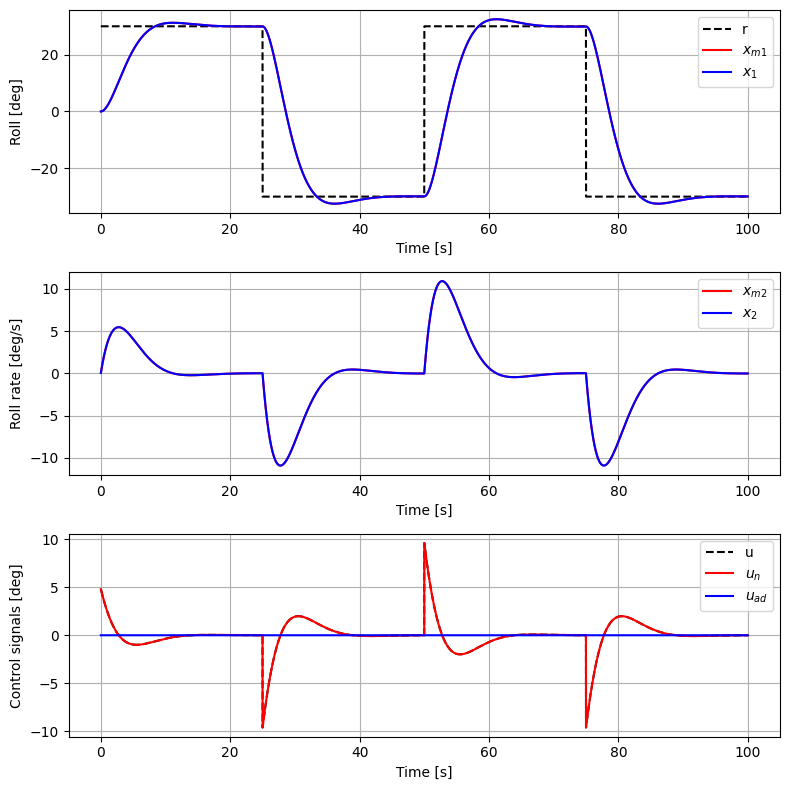

In [2]:
def simulate_MRAC(uncertainty=False, adaptation=False, T=100, gamma=1):
    dt = 0.01
    time = np.arange(0, T, dt)
    
    # Plant
    A = np.array([[0, 1], [0, 0]])
    B = np.array([0, 1])
    X = np.array([0, 0])
    Xm = np.array([0, 0])

    # Disturbance 
    alpha = np.array([
        0.2314, 0.7848, -0.0624, 0.0095, 0.0215
    ])

    def f_x(x):
        return np.array([x[0], x[1], np.abs(x[0])*x[1], np.abs(x[1])*x[1], x[0]**3])
        
    delta = lambda x: np.dot(alpha, f_x(x))

    # Model control loop
    K1 = np.array([0.16, 0.57])
    K2 = 0.16
    
    # Reference model
    Am = A - np.outer(B, K1)
    Bm = B * K2

    # Adaptive law
    R = np.eye(2) # Identity matrix
    P = solve_continuous_lyapunov(Am.T, -R)
    beta = f_x
    W = np.zeros(len(beta(X)))

    history = {
            'x1': [], 'xm1': [],
            'x2': [], 'xm2': [],
            'u': [], 'un': [], 'uad': [], 
            'r': [], 'dist': [], 'dist_est': []
        }
    history['time'] = time
    
    for t in time:
        r = deg2rad(30.0) if t%50 < 25 else -deg2rad(30.0)
    
        # Controller
        un = K2 * r - np.dot(K1, X)
        uad = np.dot(W, beta(X)) if adaptation else 0.0
        u = un - uad
        
        # Reference model
        dXm = Am @ Xm + Bm * r
        Xm = Xm + dXm * dt

        # Actual plant
        delta_x = delta(X) if uncertainty else 0.0
        dX = A @ X + B * (u + delta_x)
        X = X + dX * dt

        error = X - Xm

        dW = gamma * beta(X) *(error @ P @ B)
        W = W + dW * dt
    
        history['x1'].append(rad2deg(X[0]))
        history['x2'].append(rad2deg(X[1]))
        history['xm1'].append(rad2deg(Xm[0]))
        history['xm2'].append(rad2deg(Xm[1]))
        history['u'].append(rad2deg(u))
        history['un'].append(rad2deg(un))
        history['uad'].append(rad2deg(uad))
        history['r'].append(rad2deg(r))
        history['dist'].append(delta_x)
        history['dist_est'].append(uad)

    return history

def plot_history(history, adaptation=False):
    fig = plt.figure(figsize=(10, 8)) if adaptation else plt.figure(figsize=(8, 8))
    time = history['time']
    plt.subplot(2,2,1) if adaptation else plt.subplot(3,1,1)
    plt.plot(time, history['r'], 'k--', label=r'r')
    plt.plot(time, history['xm1'], 'r', label=r'$x_{m1}$')
    plt.plot(time, history['x1'], 'b', label=r'$x_1$')
    plt.xlabel('Time [s]')
    plt.ylabel('Roll [deg]')
    plt.grid()
    plt.legend()
    
    plt.subplot(2,2,2) if adaptation else plt.subplot(3,1,2)
    plt.plot(time, history['xm2'], 'r', label=r'$x_{m2}$')
    plt.plot(time, history['x2'], 'b', label=r'$x_2$')
    plt.xlabel('Time [s]')
    plt.ylabel('Roll rate [deg/s]')
    plt.grid()
    plt.legend()
    
    plt.subplot(2,2,3) if adaptation else plt.subplot(3,1,3)
    plt.plot(time, history['u'], 'k--', label=r'u')
    plt.plot(time, history['un'], 'r', label=r'$u_n$')
    plt.plot(time, history['uad'], 'b', label=r'$u_{ad}$')
    plt.xlabel('Time [s]')
    plt.ylabel('Control signals [deg]')
    plt.grid()
    plt.legend()

    if adaptation:
        plt.subplot(2,2,4)
        plt.plot(time, history['dist'], 'r', label=r'$W^\top \beta$')
        plt.plot(time, history['dist_est'], 'b', label=r'$\hat{W}^\top \beta$')
        plt.xlabel('Time [s]')
        plt.ylabel('Disturbance')
        plt.grid()
        plt.legend()
    
    plt.tight_layout()
    plt.show()

history = simulate_MRAC()
plot_history(history)

#### System with uncertainty but without adaptation
$u_{ad} = 0$ and $\Delta(x(t)) \neq 0$

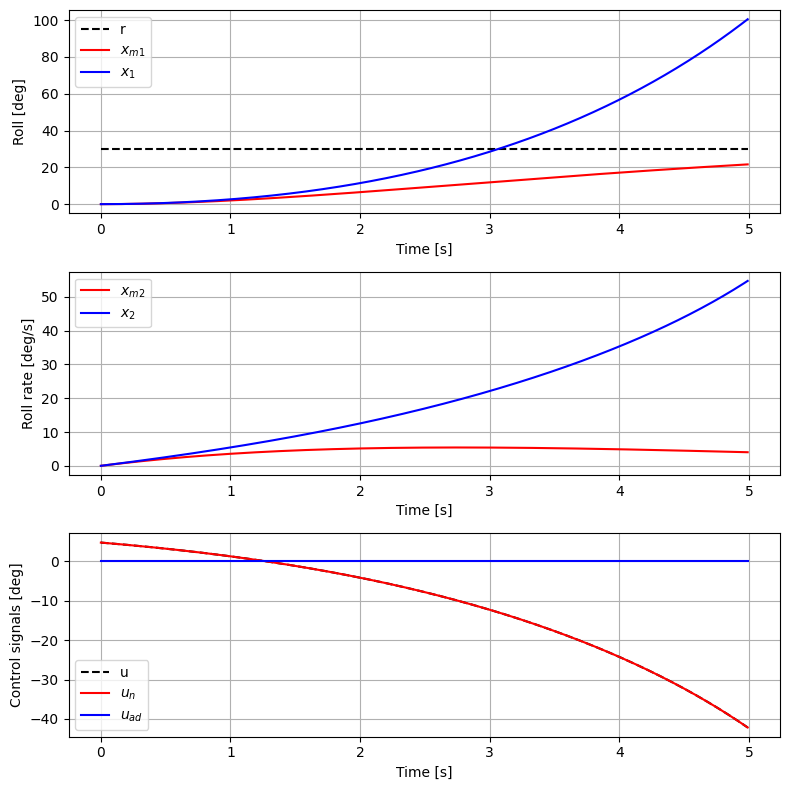

In [3]:
history = simulate_MRAC(uncertainty=True, T=5)
plot_history(history)

#### Moderate Learning Rate ($\Gamma = 1$)

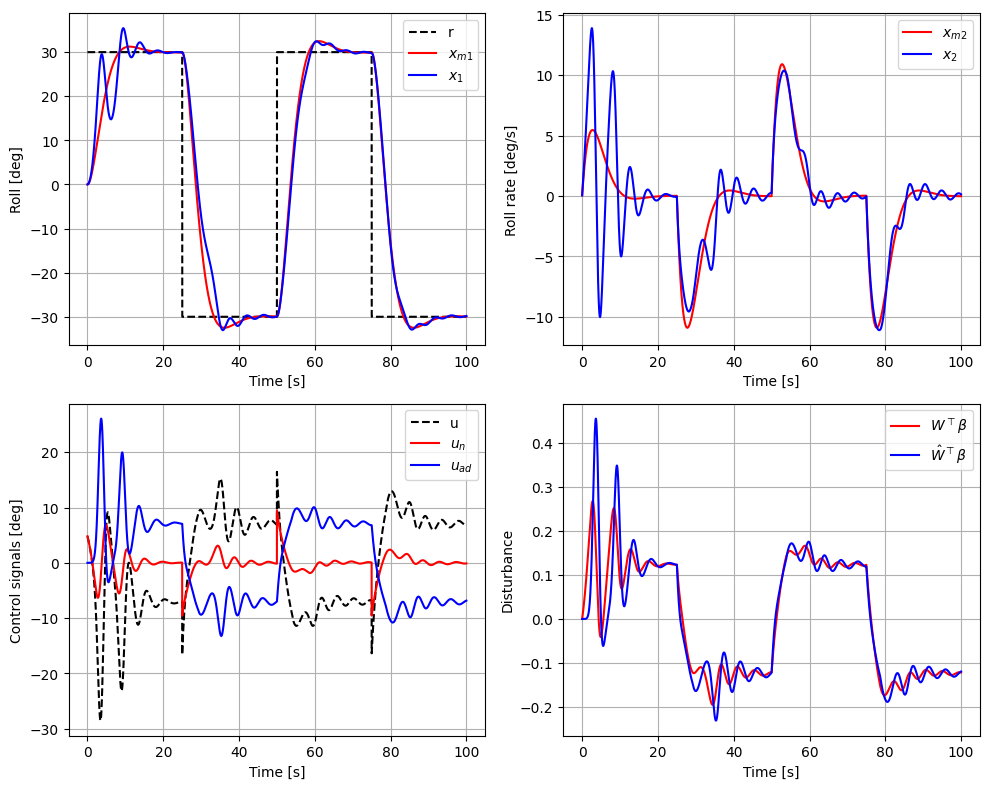

In [4]:
history = simulate_MRAC(uncertainty=True, T=100, adaptation=True, gamma=1)
plot_history(history, adaptation=True)

## Matched Uncertainty with Unknown Control Effectiveness

Let's consider the following nonlinear uncertain system dynamics

$$\dot{x}(t) = Ax(t) + B\Lambda\,[u(t)+\Delta(x(t))]$$

Where:
* $x(t) \in \mathbb{R}^n$ is the state vector
* $u(t) \in \mathbb{R}^m$ is the control ouput
* $A \in \mathbb{R}^{n\times n}$ is a **known** system matrix
* $B \in \mathbb{R}^{m \times m}$ is a **known** input matrix
* $\Delta: \mathbb{R}^{n} \to \mathbb{R}^{m}$ is the **matched uncertainty**
* $\Lambda: \in  \mathbb{R}^{m \times m}$ is an **unknown** symmetric, positive-definite matrix representing actuator gain uncertainty. For example partial rotor failure, unknown thrust-to-voltage mapping, or uncertain actuator scaling. The uncertainty is still matched (enters through $B\Lambda$), but now we don't know how much authority we have. 
This models: actuator degradation (one motor at 60% of nominal), uncertain propeller efficiency, unknown mass scaling that affects the effective $B$.

Pd: the pair $(A, B)$ is controllable

###  Matching Conditions

Since $\Lambda$ is unknown, we can no longer use $K_1, K_2$ directly.
Instead, we posit the existence of **ideal (unknown) gains** $K_1^*, K_2^*$ satisfying:

$$A - B\Lambda K_1^* = A_m, \qquad B\Lambda K_2^* = B_m$$

These are the **matching conditions** — they guarantee the reference model is achievable if we knew $\Lambda$.

### Control law 

$$u(t) = \underbrace{-\hat{K}_1(t)x(t) + \hat{K}_2(t)r(t)}_{\text{nominal (adaptive gains)}} \underbrace{- \hat{W}^\top(t)\beta(x(t))}_{\text{adaptive uncertainty cancellation}}$$

### Error Dynamics

Define the parameter errors:
$$\tilde{K}_1 = \hat{K}_1 - K_1^*, \quad \tilde{K}_2 = \hat{K}_2 - K_2^*, \quad \tilde{W} = \hat{W} - W$$

Substituting the controller into the plant:

$$ \begin{aligned}
\dot{x} &= Ax + B\Lambda\!\left[-\hat{K}_1 x + \hat{K}_2 r - \hat{W}^\top\beta(x) + W^\top\beta(x)\right]\\
&= Ax - B\Lambda K_1^* x + B\Lambda K_2^* r - B\Lambda\tilde{K}_1 x + B\Lambda\tilde{K}_2 r - B\Lambda\tilde{W}^\top\beta(x)\\
&= A_m x + B_m r - B\Lambda\!\left[\tilde{K}_1 x - \tilde{K}_2 r + \tilde{W}^\top\beta(x)\right]
\end{aligned}$$

So the error $e = x - x_m$ satisfies:

$$\boxed{\dot{e}(t) = A_m e(t) - B\Lambda\!\left[\tilde{K}_1(t) x(t) - \tilde{K}_2(t) r(t) + \tilde{W}^\top(t)\beta(x(t))\right]}$$

### Lyapunov analysis
The Lyapunov function must be positive definite in the (sub)system  $(e, \tilde{K}_1, \tilde{K}_2, \tilde{W})$, and structured so that $\Lambda$ cancels when we differentiate, yielding update laws independent of $\Lambda$ (because it's unknown).
The key trick is including $\Lambda^{-1}$ (which exists since $\Lambda > 0$) to make cross-terms cancel:

$$\boxed{V = e^\top P e + \underbrace{\text{tr}\!\left(\tilde{K}_1 \,\Gamma_1^{-1}\, \tilde{K}_1^\top \Lambda\right)}_{V_{K_1}} + \underbrace{\text{tr}\!\left(\tilde{K}_2 \,\Gamma_2^{-1}\, \tilde{K}_2^\top \Lambda\right)}_{V_{K_2}} + \underbrace{\text{tr}\!\left(\tilde{W}^\top \Gamma_W^{-1} \Lambda^{-1} \tilde{W}\right)}_{V_W}}$$

**Dimension checks:**
- $V_{K_1}$: $\underbrace{\tilde{K}_1}_{m\times n}\underbrace{\Gamma_1^{-1}}_{n\times n}\underbrace{\tilde{K}_1^\top}_{n\times m}\underbrace{\Lambda}_{m\times m} = (m\times m)$, trace is scalar.
- $V_{K_2}$: $\underbrace{\tilde{K}_2}_{m\times p}\underbrace{\Gamma_2^{-1}}_{p\times p}\underbrace{\tilde{K}_2^\top}_{p\times m}\underbrace{\Lambda}_{m\times m} = (m\times m)$, trace is scalar.
- $V_W$: $\underbrace{\tilde{W}}_{s\times m}\underbrace{\Lambda}_{m\times m}\underbrace{\tilde{W}^\top}_{m\times s}\underbrace{\Gamma_W^{-1}}_{s\times s} = (s\times s)$, trace is scalar.

**Positive definiteness.** $V > 0$ for $(e, \tilde{K}_1, \tilde{K}_2, \tilde{W}) \neq 0$ since $P > 0$, and for any quadratic form $\text{tr}(A M A^\top N)$ with $M, N > 0$, it is zero if and only if $A = 0$. Since $\Gamma_i > 0$ and $\Lambda > 0$, each trace term is positive definite.

### Recalling Matrix Properties

#### 1. Trace Identities

These are the only tools needed for the entire analysis. State them once, prove them once, then just cite them.

##### Identity T1 — Scalar equals its own trace
$$s = \text{tr}(s) \quad \text{for any scalar } s \in \mathbb{R}$$
This is trivially true since a $1\times 1$ matrix has trace equal to its single entry.

##### Identity T2 — Cyclic property of trace
$$\text{tr}(ABC) = \text{tr}(BCA) = \text{tr}(CAB)$$
More generally, factors can be cyclically permuted. This holds for any compatible matrices.

**Proof:** $\text{tr}(ABC) = \sum_i (ABC)_{ii} = \sum_i \sum_j \sum_k A_{ij}B_{jk}C_{ki}$. Reindexing the same sum gives $\text{tr}(BCA)$ and $\text{tr}(CAB)$.

##### Identity T3 — Transpose invariance of trace
$$\text{tr}(A) = \text{tr}(A^\top)$$
**Proof:** Diagonal entries are unchanged by transposition.

#### 2.  Converting a Scalar Product to a Trace

This is the workhorse identity that makes the whole derivation possible. Derive it once in full generality.

**Lemma.** Let $a \in \mathbb{R}^{n\times 1}$, $M \in \mathbb{R}^{n\times m}$ (both given/fixed), and $X \in \mathbb{R}^{m\times n}$ (the parameter of interest). Then:
$$a^\top M X b = \text{tr}\!\left(X^\top M^\top a b^\top\right) \quad \text{for any } b \in \mathbb{R}^{n\times 1}$$
or written with any symmetric $S \in \mathbb{R}^{m\times m}$:
$$a^\top M S X b = \text{tr}\!\left(X^\top S M^\top a b^\top\right) \quad \text{(when }S=S^\top\text{)}$$

**Proof of the first form:**

Step 1 — Apply T1:
$$a^\top M X b = \text{tr}(a^\top M X b)$$

Step 2 — Apply T2 cyclically (group $a^\top M X$ as one factor and $b$ as the other):
$$= \text{tr}(b \cdot a^\top M X) = \text{tr}(b \, a^\top M X)$$

Step 3 — Apply T3 to the entire matrix inside the trace:
$$= \text{tr}\!\left((b \, a^\top M X)^\top\right) = \text{tr}\!\left(X^\top M^\top a b^\top\right)$$

**This is exactly the step that isolates the parameter matrix $X$ (or $\tilde{K}_1$, $\tilde{W}$, etc.) so it can be compared with the Lyapunov differentiation term.**

#### 3. Time Derivative of a Quadratic Trace Term

**Lemma.** For constant matrices $M = M^\top > 0$ and $N = N^\top > 0$, and time-varying $A(t)$:
$$\frac{d}{dt}\,\text{tr}\!\left(A \, M \, A^\top N\right) = 2\,\text{tr}\!\left(\dot{A} \, M \, A^\top N\right)$$

**Proof:**

Apply the product rule to the trace (trace and derivative commute since they are both linear):
$$\frac{d}{dt}\,\text{tr}(A M A^\top N) = \text{tr}(\dot{A} M A^\top N) + \text{tr}(A M \dot{A}^\top N)$$

For the second term, apply T3:
$$\text{tr}(A M \dot{A}^\top N) = \text{tr}\!\left((A M \dot{A}^\top N)^\top\right) = \text{tr}(N^\top \dot{A} M^\top A^\top)$$

Since $M = M^\top$ and $N = N^\top$:
$$= \text{tr}(N \dot{A} M A^\top)$$

Apply T2 cyclically:
$$= \text{tr}(\dot{A} M A^\top N)$$

Therefore both terms are equal and:
$$\frac{d}{dt}\,\text{tr}(A M A^\top N) = 2\,\text{tr}(\dot{A} M A^\top N)$$

### Computing $\dot{V}$

Taking the time derivative and using $\dot{\tilde{K}}_i = \dot{\hat{K}}_i$, $\dot{\tilde{W}} = \dot{\hat{W}}$:

$$\dot{V} = \underbrace{2e^\top P \dot{e}}_{\text{error term}} + \underbrace{\dot{V}_{K_1}}_{\text{gain 1 term}} + \underbrace{\dot{V}_{K_2}}_{\text{gain 2 term}} + \underbrace{\dot{V}_W}_{W \text{ term}}$$

#### Expand the Error Term

Substituting the error dynamics:
$$2e^\top P \dot{e} = 2e^\top P A_m e - 2e^\top P B\Lambda \tilde{K}_1 x + 2e^\top P B\Lambda \tilde{K}_2 r - 2e^\top P B\Lambda \tilde{W}^\top \beta$$

The first term is immediately:
$$2e^\top P A_m e = e^\top(P A_m + A_m^\top P)e = -e^\top R e$$
(using the Lyapunov equation $A_m^\top P + PA_m + R = 0$)

The remaining three terms are scalars involving the parameter errors $\tilde{K}_1$, $\tilde{K}_2$, $\tilde{W}$. We need to convert each into a trace expression so we can combine it with the corresponding $\dot{V}_{K_i}$, $\dot{V}_W$ term.

#### Computing  $\dot{V}_{K_1}$
Recalling the time derivatice of a quadratic trace term we get 
$$\dot{V}_{K_1} = 2\,\text{tr}(\dot{\hat{K}}_1 \,\Gamma_1^{-1}\, \tilde{K}_1^\top \Lambda)$$

Recalling the cyclic propertiy of the trace we reorganize it:
$$\dot{V}_{K_1} = 2\,\text{tr}(\tilde{K}_1^\top \Lambda \,\dot{\hat{K}}_1\, \Gamma_1^{-1})$$

#### Computing  $\dot{V}_{K_2}$
Similar as $\dot{V}_{K_1}$
$$\dot{V}_{K_2} = 2\,\text{tr}(\tilde{K}_2^\top \Lambda \,\dot{\hat{K}}_2\, \Gamma_2^{-1})$$

#### Computing  $\dot{V}_{W}$
For  $\dot{V}_{W}$ we use the product rule:
$$\dot{V}_W = \text{tr}(\dot{\tilde{W}}\,\Lambda\,\tilde{W}^\top \Gamma_W^{-1}) + \text{tr}(\tilde{W}\,\Lambda\,\dot{\tilde{W}}^\top \Gamma_W^{-1})$$

Apply T3 to the second term:
$$\text{tr}(\tilde{W}\Lambda\dot{\tilde{W}}^\top \Gamma_W^{-1}) = \text{tr}\!\left((\tilde{W}\Lambda\dot{\tilde{W}}^\top \Gamma_W^{-1})^\top\right) = \text{tr}(\Gamma_W^{-1}\dot{\tilde{W}}\Lambda^\top\tilde{W}^\top) = \text{tr}(\Gamma_W^{-1}\dot{\tilde{W}}\Lambda\tilde{W}^\top)$$

Apply T2:
$$= \text{tr}(\dot{\tilde{W}}\Lambda\tilde{W}^\top\Gamma_W^{-1})$$

Both terms are equal, so:
$$\dot{V}_W = 2\,\text{tr}(\dot{\hat{W}}\,\Lambda\,\tilde{W}^\top \Gamma_W^{-1})$$

Apply T2 one more time to reorganize (cycle $\dot{\hat{W}} \to \Lambda \to \tilde{W}^\top \to \Gamma_W^{-1}$):
$$= 2\,\text{tr}(\tilde{W}^\top \Gamma_W^{-1} \dot{\hat{W}}\,\Lambda)$$

Apply T3:
$$= 2\,\text{tr}(\Lambda^\top \dot{\hat{W}}^\top \Gamma_W^{-\top} \tilde{W}) = 2\,\text{tr}(\tilde{W}\,\Lambda\,\dot{\hat{W}}^\top \Gamma_W^{-1})$$

We will use the form:
$$\dot{V}_W = 2\,\text{tr}(\tilde{W}\,\Lambda\,\dot{\hat{W}}^\top\,\Gamma_W^{-1})$$

#### Converting each error term to trace

##### Term 1: $-2e^\top PB\Lambda\,\tilde{K}_1 x$

This is a scalar with $\tilde{K}_1 \in \mathbb{R}^{m\times n}$ as the parameter. Apply T1:
$$e^\top P B \Lambda \tilde{K}_1 x = \text{tr}(e^\top P B \Lambda \tilde{K}_1 x)$$

Group as two matrices for T2: $A_1 = (e^\top P B \Lambda) \in \mathbb{R}^{1\times m}$ and $A_2 = (\tilde{K}_1 x) \in \mathbb{R}^{m\times 1}$:
$$= \text{tr}(A_1 A_2) = \text{tr}(A_2 A_1) = \text{tr}\!\left(\tilde{K}_1 x \cdot e^\top P B \Lambda\right)$$

The result is $(m\times n)(n\times 1)(1\times n)(n\times n)(n\times m)(m\times m) \to (m\times m)$ ✓. Apply T3:
$$\text{tr}(\tilde{K}_1 x e^\top P B \Lambda) = \text{tr}\!\left((\tilde{K}_1 x e^\top P B \Lambda)^\top\right) = \text{tr}(\Lambda^\top B^\top P e\, x^\top \tilde{K}_1^\top)$$

Since $\Lambda = \Lambda^\top$ and $P = P^\top$:
$$= \text{tr}(\Lambda B^\top P e\, x^\top \tilde{K}_1^\top)$$

Apply T2 (cycle $\Lambda$ to the end):
$$= \text{tr}(\tilde{K}_1^\top \Lambda B^\top P e\, x^\top)$$

So the scalar cross-term becomes:
$$-2e^\top P B \Lambda \tilde{K}_1 x = -2\,\text{tr}(\tilde{K}_1^\top \Lambda B^\top P e\, x^\top)$$

##### Term 2: $+2e^\top PB\Lambda\,\tilde{K}_2 r$

Identical steps (note the $+$ sign), replacing $x$ with $r$ and $\tilde{K}_1$ with $\tilde{K}_2$:
$$+2e^\top P B \Lambda \tilde{K}_2 r = +2\,\text{tr}(\tilde{K}_2^\top \Lambda B^\top P e\, r^\top)$$

##### Term 3: $-2e^\top PB\Lambda\,\tilde{W}^\top\beta$

Here $\tilde{W}^\top \in \mathbb{R}^{m\times s}$ and $\beta \in \mathbb{R}^s$, so $\tilde{W}^\top\beta \in \mathbb{R}^m$ and the product $B\Lambda\tilde{W}^\top\beta \in \mathbb{R}^n$. The scalar is:

Apply T1, then T2 grouping $A_1 = (e^\top P B \Lambda) \in \mathbb{R}^{1\times m}$ and $A_2 = (\tilde{W}^\top\beta) \in \mathbb{R}^{m\times 1}$:
$$e^\top P B \Lambda \tilde{W}^\top \beta = \text{tr}(\tilde{W}^\top\beta \cdot e^\top P B \Lambda) = \text{tr}(\tilde{W}^\top \underbrace{\beta e^\top P B \Lambda}_{\in\, \mathbb{R}^{s\times m}})$$

Apply T3:
$$= \text{tr}\!\left((\tilde{W}^\top \beta e^\top P B \Lambda)^\top\right) = \text{tr}(\Lambda^\top B^\top P e\, \beta^\top \tilde{W}) = \text{tr}(\Lambda B^\top P e\, \beta^\top \tilde{W})$$

Apply T2 (cycle $\tilde{W}$ to front):
$$= \text{tr}(\tilde{W}\,\Lambda B^\top P e\, \beta^\top)$$

So:
$$-2e^\top P B \Lambda \tilde{W}^\top \beta = -2\,\text{tr}(\tilde{W}\,\Lambda B^\top P e\,\beta^\top)$$

### Assembling $\dot{V}$ and Deriving Update Laws

Now assemble everything. Group terms by parameter:

$$\dot{V} = -e^\top R e$$
$$+ 2\,\text{tr}\!\left(\tilde{K}_1^\top \Lambda \!\left[\dot{\hat{K}}_1 \Gamma_1^{-1} - B^\top P e\, x^\top\right]\!\right)$$
$$+ 2\,\text{tr}\!\left(\tilde{K}_2^\top \Lambda \!\left[\dot{\hat{K}}_2 \Gamma_2^{-1} + B^\top P e\, r^\top\right]\!\right)$$
$$+ 2\,\text{tr}\!\left(\tilde{W}\,\Lambda\!\left[\dot{\hat{W}}^\top \Gamma_W^{-1} - B^\top P e\,\beta^\top\right]\!\right)$$

For each bracket we want it to equal zero for all values of $\tilde{K}_1$, $\tilde{K}_2$, $\tilde{W}$. Since $\Lambda > 0$ and $\text{tr}(M^\top \Lambda \cdot [\,\cdot\,]) = 0$ for all $M$ implies $[\,\cdot\,] = 0$, we set each bracket to zero:

**From bracket 1:**
$$\dot{\hat{K}}_1 \Gamma_1^{-1} = B^\top P e\, x^\top \implies \boxed{\dot{\hat{K}}_1(t) = B^\top P\, e(t)\, x^\top(t)\, \Gamma_1}$$

**From bracket 2:**
$$\dot{\hat{K}}_2 \Gamma_2^{-1} = -B^\top P e\, r^\top \implies \boxed{\dot{\hat{K}}_2(t) = -B^\top P\, e(t)\, r^\top(t)\, \Gamma_2}$$

**From bracket 3:**
$$\dot{\hat{W}}^\top \Gamma_W^{-1} = B^\top P e\,\beta^\top \implies \dot{\hat{W}}^\top = B^\top P e\,\beta^\top \Gamma_W \implies \boxed{\dot{\hat{W}}(t) = \Gamma_W\,\beta(x(t))\,e^\top(t) P B}$$

**Crucially: $\Lambda$ does not appear in any update law.** The $\Lambda$ embedded in the Lyapunov function perfectly matches the $\Lambda$ from the error dynamics, and they cancel algebraically in each bracket before yielding the update rule.

After cancellation:
$$\dot{V}(e, \tilde{K}_1, \tilde{K}_2, \tilde{W}) = -e^\top R\, e \leq 0$$

## Hands On Python implementation

### 1.  System Definition
Continuing with the wind rock example. Now let's suppose we have a **degraded actuator**. 
Physically, this models a damaged control surface, partial hydraulic failure, or an unknown aerodynamic scaling.
Mathematically, the plant becomes:

$$\dot{x}(t) = Ax(t) + B\Lambda\left[u(t) + \Delta(x(t))\right], \qquad \Lambda = 0.5$$

where $\Lambda = 0.5$ is unknown to the controller (simulating 50% actuator effectiveness).

With $\Lambda \neq 1$, the nominal gains $K_1, K_2$ no longer satisfy the matching conditions. Specifically:

$$A - B\underbrace{\Lambda}_{0.5} K_1 \neq A_m = A - BK_1$$

The effective closed-loop matrix is $A - 0.5BK_1$, which is **not** $A_m$. The residual $(0.5 B K_1 x - B K_1 x) = -0.5 BK_1 x$ acts as an uncompensated term that $\hat{W}$ alone cannot absorb (it would require $\hat{W}$ to grow without bound to compensate a term that scales with $x$).

In [14]:
from scipy.integrate import solve_ivp
import matplotlib.gridspec as gridspec

In [5]:
A = np.array([[0., 1.],
              [0., 0.]])
B = np.array([[0.], [1.]])          # (2,1)
 
Lambda_true = 0.5                   # unknown 50% actuator effectiveness
 
W_true = np.array([[ 0.2314],       # (5,1)  unknown uncertainty weights
                   [ 0.7848],
                   [-0.0624],
                   [ 0.0095],
                   [ 0.0215]])

### 2.  Reference Model
Designed assuming $\Lambda = 1$  (nominal design), $\omega_n = 0.40$ rad/s,  $zeta = 0.707$

The nominal gains we obtained in the past example:
$$
\begin{aligned}
K_1 &= \begin{bmatrix} 0.16, \ 0.57\end{bmatrix}\\
K_2 &= 0.16
\end{aligned}
$$

In [6]:
K1_nom = np.array([[0.16, 0.57]])   # (1,2)
K2_nom = np.array([[0.16]])         # (1,1)
 
Am = A - B @ K1_nom                 # (2,2)  Hurwitz
Bm = B @ K2_nom                     # (2,1)
 
# Lyapunov equation:  Am'P + P Am + I = 0
P = solve_continuous_lyapunov(Am.T, -np.eye(2))

#### 3. Ideal matching gains
There exist unknown ideal gains $K_1^*, K_2^*$ satisfying:

$$A - B\Lambda K_1^* = A_m \implies K_1^* = \frac{K_1}{\Lambda} = \begin{bmatrix}0.32, \ 1.14\end{bmatrix}$$

$$B\Lambda K_2^* = B_m \implies K_2^* = \frac{K_2}{\Lambda} = 0.32$$

The controller **does not know** $K_1^*, K_2^*$ (since it doesn't know $\Lambda$), so it must adapt $\hat{K}_1(t) \to K_1^*$ and $\hat{K}_2(t) \to K_2^*$ online.


In [7]:
K1_star = K1_nom / Lambda_true      # (1,2)  = [[0.32, 1.14]]
K2_star = K2_nom / Lambda_true      # (1,1)  = [[0.32]]

### 4. Basis function $\beta: \mathbb{R}^2 \to \mathbb{R}^5$

For this example $x_1$ corresponds to the roll angle in radians, and $x_2$ is the roll rate in radians per second.
The parameterization of the uncertainty follows:
$$
\begin{aligned}
\Delta(x) &= \alpha_1 x_1 + \alpha_2 x_2 + \alpha_3 |x_1|x_2 + \alpha_4 |x_2|x_2 + \alpha_5 x^3_1\\
&= \underbrace{\begin{bmatrix}\alpha_1,\ \alpha_2,\ \alpha_3,\ \alpha_4,\ \alpha_5 \end{bmatrix}}_{W^\top} \underbrace{\begin{bmatrix}x_1,\ x_2,\ |x_1|x_2,\ |x_2|x_2,\ x^3_1 \end{bmatrix}}_{\beta(x)} \\
\end{aligned}
$$

In [8]:
def beta(x):
    x1, x2 = x[0], x[1]
    return np.array([x1,
                     x2,
                     abs(x1) * x2,
                     abs(x2) * x2,
                     x1 ** 3])      # (5,)

### 5. Reference Command

In [21]:
def r_func(t):
    """Step to 10 deg at t=5s, back to 0 at t=50s."""
    if t < 5.0:
        return 0.0
    elif t < 50.0:
        return np.deg2rad(10.0)
    else:
        return 0.0

### 6. Adaption gains

In [10]:
gamma1 = 5.0     # K1hat adaptation rate
gamma2 = 5.0     # K2hat adaptation rate
gammaW = 5.0     # What  adaptation rate

### 7. Nominal model (only uncertainty adaption) K1/K2 Fixed

In [11]:
# State z = [x(2), xm(2), What(5)]   total = 9
def ode_form1(t, z):
    x    = z[0:2]
    xm   = z[2:4]
    What = z[4:9].reshape(5, 1)
 
    r = r_func(t)
    b = beta(x).reshape(5, 1)               # (5,1)
    e = (x - xm).reshape(2, 1)              # (2,1)
 
    # B'Pe  — scalar for m=1
    BTPe = float((B.T @ P @ e).ravel()[0])
 
    # Controller:  fixed nominal gains, only uncertainty adaptive term
    u = float((-K1_nom @ x.reshape(2, 1) + K2_nom * r - What.T @ b).ravel()[0])
 
    # True plant
    Delta = float((W_true.T @ b).ravel()[0])
    x_dot = A @ x + B.flatten() * Lambda_true * (u + Delta)
 
    # Reference model
    xm_dot = Am @ xm + Bm.flatten() * r
 
    # Only What update law
    What_dot = gammaW * b * BTPe            # (5,1)
 
    return np.concatenate([x_dot, xm_dot, What_dot.flatten()])

### 8. Full adaption model K1/K2/W adapted

In [12]:
#  State z = [x(2), xm(2), K1hat(2), K2hat(1), What(5)]  total = 12
def ode_form2(t, z):
    x     = z[0:2]
    xm    = z[2:4]
    K1hat = z[4:6].reshape(1, 2)            # (1,2)
    K2hat = float(z[6])                      # scalar
    What  = z[7:12].reshape(5, 1)           # (5,1)
 
    r = r_func(t)
    b = beta(x).reshape(5, 1)               # (5,1)
    e = (x - xm).reshape(2, 1)              # (2,1)
 
    # B'Pe  — scalar for m=1  (same scalar drives all three update laws)
    BTPe = float((B.T @ P @ e).ravel()[0])
 
    # Controller with adaptive gains
    u = float((-K1hat @ x.reshape(2, 1) + K2hat * r - What.T @ b).ravel()[0])
 
    # True plant
    Delta = float((W_true.T @ b).ravel()[0])
    x_dot = A @ x + B.flatten() * Lambda_true * (u + Delta)
 
    # Reference model
    xm_dot = Am @ xm + Bm.flatten() * r
 
    # ── Update Laws ──────────────────────────────────────────────
    # K1hat_dot = gamma1 * (B'Pe) * x'      (1,2)
    K1hat_dot = gamma1 * BTPe * x.reshape(1, 2)
 
    # K2hat_dot = -gamma2 * (B'Pe) * r      scalar
    K2hat_dot = -gamma2 * BTPe * r
 
    # What_dot  = gammaW * beta(x) * (e'PB)  (5,1)   note e'PB = BTPe scalar
    What_dot = gammaW * b * BTPe
 
    return np.concatenate([
        x_dot,
        xm_dot,
        K1hat_dot.flatten(),
        [K2hat_dot],
        What_dot.flatten()
    ])

### 9. Simulation

In [23]:
x0  = np.zeros(2)
xm0 = np.zeros(2)
 
# Form 1: x, xm, What=0
z0_form1 = np.concatenate([x0, xm0, np.zeros(5)])
 
# Form 2: x, xm, K1hat=K1_nom (nominal guess), K2hat=K2_nom, What=0
#   The controller knows Am but not Lambda, so it starts from the nominal design
z0_form2 = np.concatenate([x0, xm0, K1_nom.flatten(), [float(K2_nom.flatten()[0])], np.zeros(5)])
 
T_end  = 100.0
t_eval = np.linspace(0, T_end, 6000)
 
sol1 = solve_ivp(ode_form1, (0, T_end), z0_form1, t_eval=t_eval, rtol=1e-9, atol=1e-11)
sol2 = solve_ivp(ode_form2, (0, T_end), z0_form2, t_eval=t_eval, rtol=1e-9, atol=1e-11)
 
t = sol1.t
 
# ── Extract signals ───────────────────────────────────────────────
x1_f1,  x2_f1  = sol1.y[0],    sol1.y[1]
xm1,    xm2    = sol1.y[2],    sol1.y[3]
What_f1        = sol1.y[4:9]                # (5, T)
 
x1_f2,  x2_f2  = sol2.y[0],    sol2.y[1]
K1hat_f2        = sol2.y[4:6]               # (2, T)
K2hat_f2        = sol2.y[6]                 # (T,)
What_f2         = sol2.y[7:12]              # (5, T)
 
r_vals = np.array([r_func(ti) for ti in t])

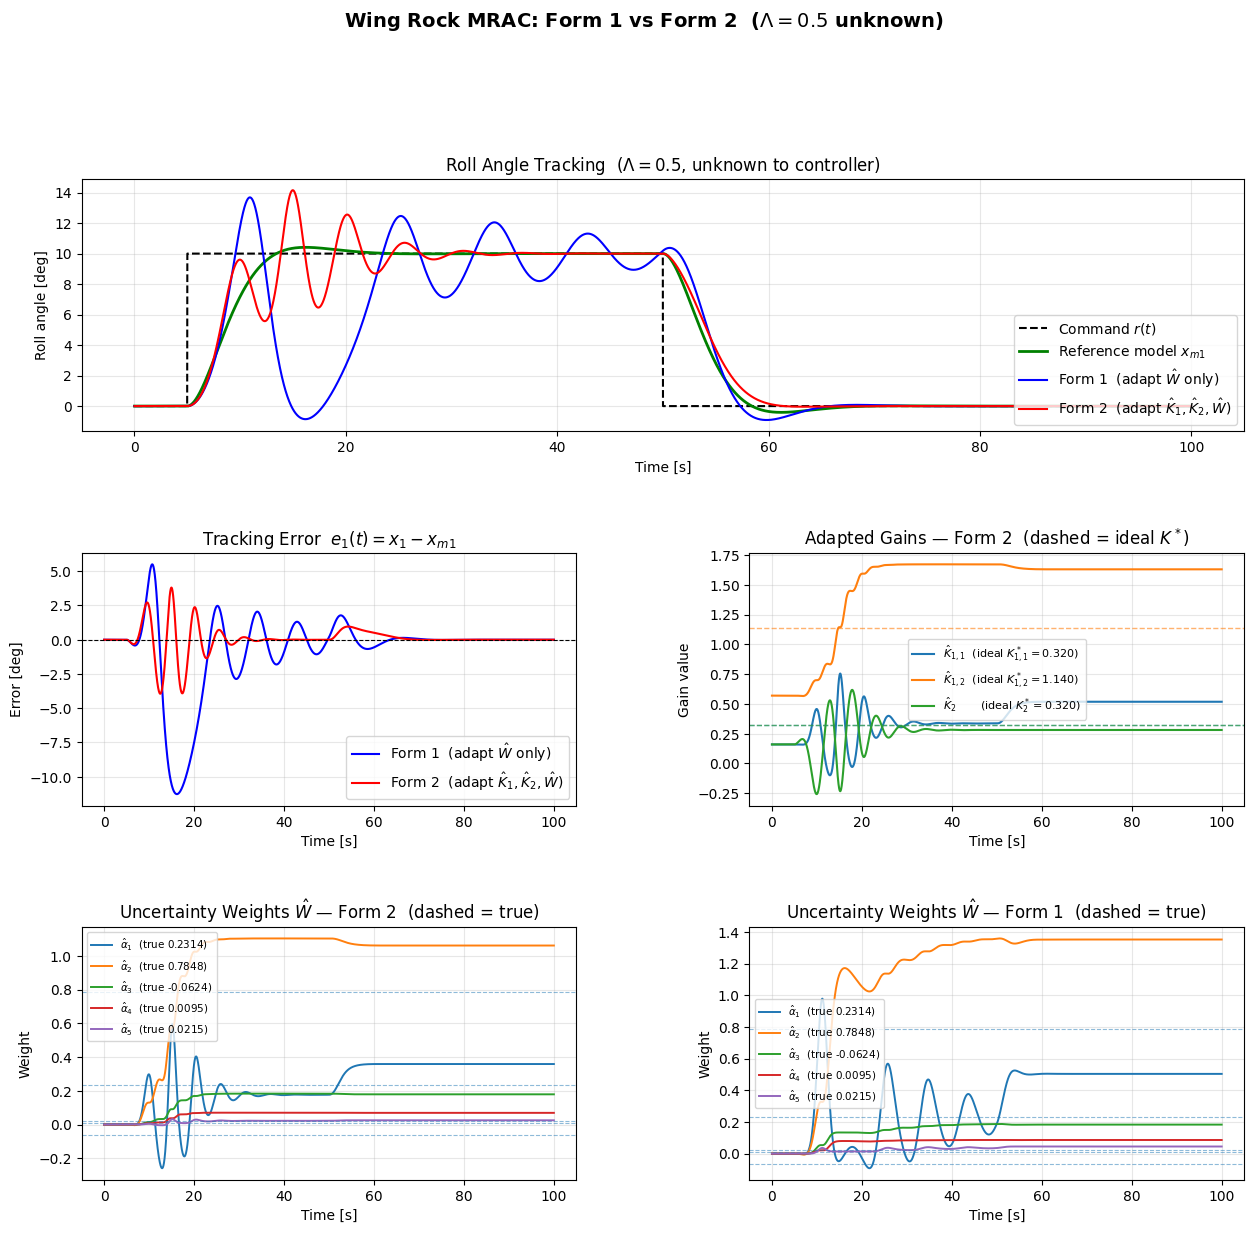

In [24]:
fig = plt.figure(figsize=(15, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.35)
 
label_f1 = r'Form 1  (adapt $\hat{W}$ only)'
label_f2 = r'Form 2  (adapt $\hat{K}_1, \hat{K}_2, \hat{W}$)'
 
# ── (a) Roll angle tracking ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t, np.rad2deg(r_vals),  'k--', lw=1.5,  label=r'Command $r(t)$')
ax1.plot(t, np.rad2deg(xm1),    'g-',  lw=2.0,  label=r'Reference model $x_{m1}$')
ax1.plot(t, np.rad2deg(x1_f1),  'b-',  lw=1.5,  label=label_f1)
ax1.plot(t, np.rad2deg(x1_f2),  'r-',  lw=1.5,  label=label_f2)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Roll angle [deg]')
ax1.set_title(r'Roll Angle Tracking  ($\Lambda = 0.5$, unknown to controller)',
              fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
 
# ── (b) Tracking error ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t, np.rad2deg(x1_f1 - xm1), 'b-', lw=1.5, label=label_f1)
ax2.plot(t, np.rad2deg(x1_f2 - xm1), 'r-', lw=1.5, label=label_f2)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Error [deg]')
ax2.set_title(r'Tracking Error  $e_1(t) = x_1 - x_{m1}$')
ax2.legend()
ax2.grid(True, alpha=0.3)
 
# ── (c) Adapted gains K1hat, K2hat (Form 2) ──────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t, K1hat_f2[0], 'C0-', lw=1.5,
         label=r'$\hat{K}_{1,1}$  (ideal $K^*_{1,1}=%.3f$)' % K1_star[0, 0])
ax3.plot(t, K1hat_f2[1], 'C1-', lw=1.5,
         label=r'$\hat{K}_{1,2}$  (ideal $K^*_{1,2}=%.3f$)' % K1_star[0, 1])
ax3.plot(t, K2hat_f2,    'C2-', lw=1.5,
         label=r'$\hat{K}_2$       (ideal $K^*_2=%.3f$)' % K2_star[0, 0])
# Ideal gain dashed lines
ax3.axhline(K1_star[0, 0], color='C0', ls='--', lw=1.0, alpha=0.6)
ax3.axhline(K1_star[0, 1], color='C1', ls='--', lw=1.0, alpha=0.6)
ax3.axhline(K2_star[0, 0], color='C2', ls='--', lw=1.0, alpha=0.6)
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Gain value')
ax3.set_title(r'Adapted Gains — Form 2  (dashed = ideal $K^*$)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
 
# ── (d) Uncertainty weights — Form 2 ─────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
names  = [r'$\hat{\alpha}_1$', r'$\hat{\alpha}_2$', r'$\hat{\alpha}_3$',
          r'$\hat{\alpha}_4$', r'$\hat{\alpha}_5$']
trueW  = W_true.flatten()
for i in range(5):
    ax4.plot(t, What_f2[i], lw=1.4, label='%s  (true %.4f)' % (names[i], trueW[i]))
    ax4.axhline(trueW[i], ls='--', lw=0.8, alpha=0.5)
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Weight')
ax4.set_title(r'Uncertainty Weights $\hat{W}$ — Form 2  (dashed = true)')
ax4.legend(fontsize=7.5)
ax4.grid(True, alpha=0.3)
 
# ── (e) Uncertainty weights — Form 1 ─────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
for i in range(5):
    ax5.plot(t, What_f1[i], lw=1.4, label='%s  (true %.4f)' % (names[i], trueW[i]))
    ax5.axhline(trueW[i], ls='--', lw=0.8, alpha=0.5)
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Weight')
ax5.set_title(r'Uncertainty Weights $\hat{W}$ — Form 1  (dashed = true)')
ax5.legend(fontsize=7.5)
ax5.grid(True, alpha=0.3)
 
plt.suptitle(r'Wing Rock MRAC: Form 1 vs Form 2  ($\Lambda = 0.5$ unknown)',
             fontsize=14, fontweight='bold', y=1.01)

plt.show()